# EDA — Eksploracja danych

Wstępna analiza komentarzy z 4 subredditów muzycznych: r/hiphopheads, r/indieheads, r/Metal, r/popheads.
Dane obejmują okres **2020-3-11 → 2021-3-11**.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/processed/all_subreddits_sample.csv")

df["date"] = pd.to_datetime(
    pd.to_numeric(df["created_utc"], errors="coerce"), unit="s"
)
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M")

print(df.shape)
df.head()

(2544183, 13)


,comment_id,author,body,subreddit,score,created_utc,parent_id,link_id,controversiality,gilded,date,year,month
0,fk5omrz,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,hiphopheads,2,1583884815,t3_fglr4p,t3_fglr4p,0,0,2020-03-11 00:00:15,2020,2020-03
1,fk5ono1,superchingonguey,Yeah I stumbled upon her about a year ago. She...,hiphopheads,2,1583884830,t1_fk5o56t,t3_fgnnun,0,0,2020-03-11 00:00:30,2020,2020-03
2,fk5osck,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...",hiphopheads,1,1583884906,t1_fk5mi66,t3_fglr4p,0,0,2020-03-11 00:01:46,2020,2020-03
3,fk5oslg,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,hiphopheads,20,1583884910,t3_fgihaz,t3_fgihaz,0,0,2020-03-11 00:01:50,2020,2020-03
4,fk5ourg,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...",hiphopheads,2,1583884946,t1_fk5o548,t3_fglr4p,0,0,2020-03-11 00:02:26,2020,2020-03


## 1. Podstawowe statystyki

In [25]:
# liczba komentarzy i unikalnych autorów per subreddit
stats = df.groupby("subreddit").agg(
    komentarzy=("comment_id", "count"),
    unikalnych_autorow=("author", "nunique"),
    sredni_score=("score", "mean"),
    mediana_score=("score", "median"),
).round(2)

stats

,komentarzy,unikalnych_autorow,sredni_score,mediana_score
subreddit,,,,
Metal,106181,17049,4.44,2.0
hiphopheads,1291468,110058,18.34,3.0
indieheads,367958,51588,9.32,3.0
popheads,778576,37077,21.09,7.0


In [26]:
# brakujące wartości
df.isnull().sum()

comment_id          0
author              0
body                0
subreddit           0
score               0
created_utc         0
parent_id           0
link_id             0
controversiality    0
gilded              0
date                0
year                0
month               0
dtype: int64

## 2. Aktywność w czasie

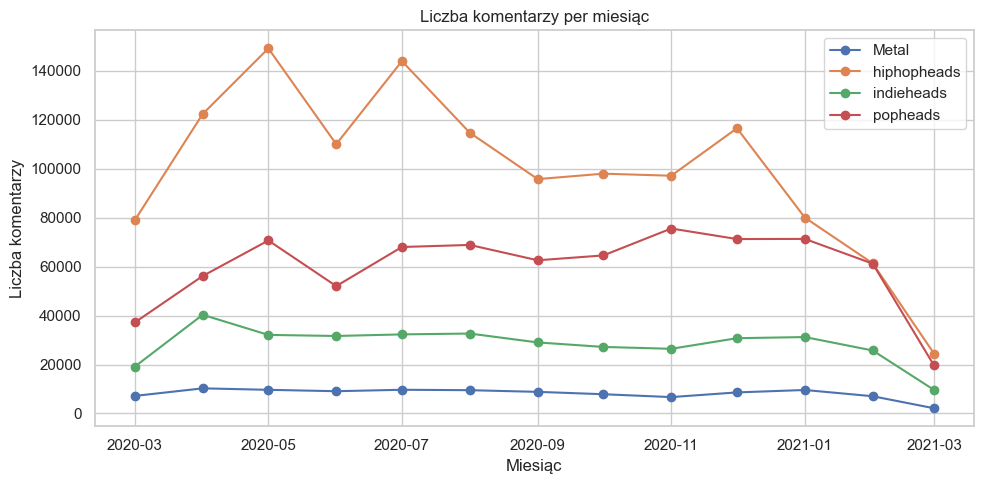

In [27]:
from pathlib import Path

activity = (
    df.groupby(["subreddit", "month"])
    .size()
    .reset_index(name="count")
)

# month to Period — trzeba zamienić na timestamp żeby matplotlib to ogarnął
activity["month_ts"] = activity["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 5))

for sub, group in activity.groupby("subreddit"):
    ax.plot(group["month_ts"], group["count"], marker="o", label=sub)

ax.set_title("Liczba komentarzy per miesiąc")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Liczba komentarzy")
ax.legend()
plt.tight_layout()
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../outputs/figures/activity_per_month.png", dpi=150)
plt.show()

## 3. Długość komentarzy

              mean  median    max
subreddit                        
Metal        187.2   106.0  10086
hiphopheads  175.1    82.0  10081
indieheads   182.2   106.0  10017
popheads     220.8   113.0  10265


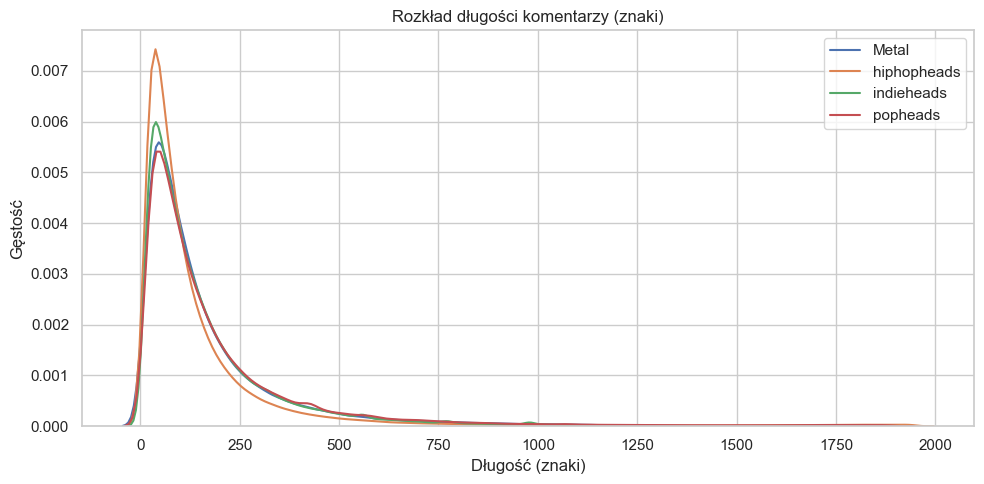

In [28]:
df["body_len"] = df["body"].str.len()

length_stats = df.groupby("subreddit")["body_len"].agg(["mean", "median", "max"]).round(1)
print(length_stats)

fig, ax = plt.subplots(figsize=(10, 5))

for sub, group in df.groupby("subreddit"):
    # przycinamy do 99 percentyla żeby outliery nie psuły wykresu
    cutoff = group["body_len"].quantile(0.99)
    sns.kdeplot(group.loc[group["body_len"] <= cutoff, "body_len"], label=sub, ax=ax)

ax.set_title("Rozkład długości komentarzy (znaki)")
ax.set_xlabel("Długość (znaki)")
ax.set_ylabel("Gęstość")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/comment_length_dist.png", dpi=150)
plt.show()

## 4. Rozkład scorów

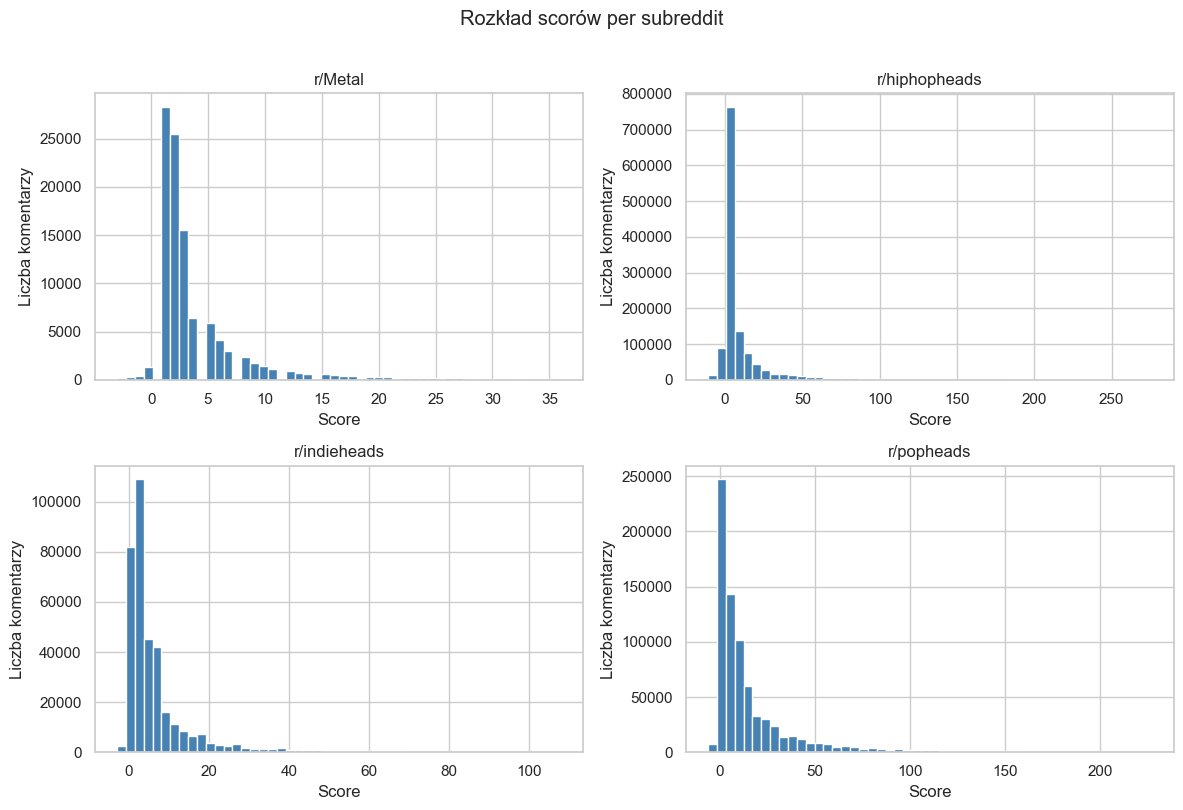

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    low  = group["score"].quantile(0.01)
    high = group["score"].quantile(0.99)
    data = group.loc[(group["score"] >= low) & (group["score"] <= high), "score"]
    
    axes[i].hist(data, bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(f"r/{sub}")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Liczba komentarzy")

plt.suptitle("Rozkład scorów per subreddit", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/score_dist.png", dpi=150)
plt.show()

## 5. Najpopularniejsi autorzy

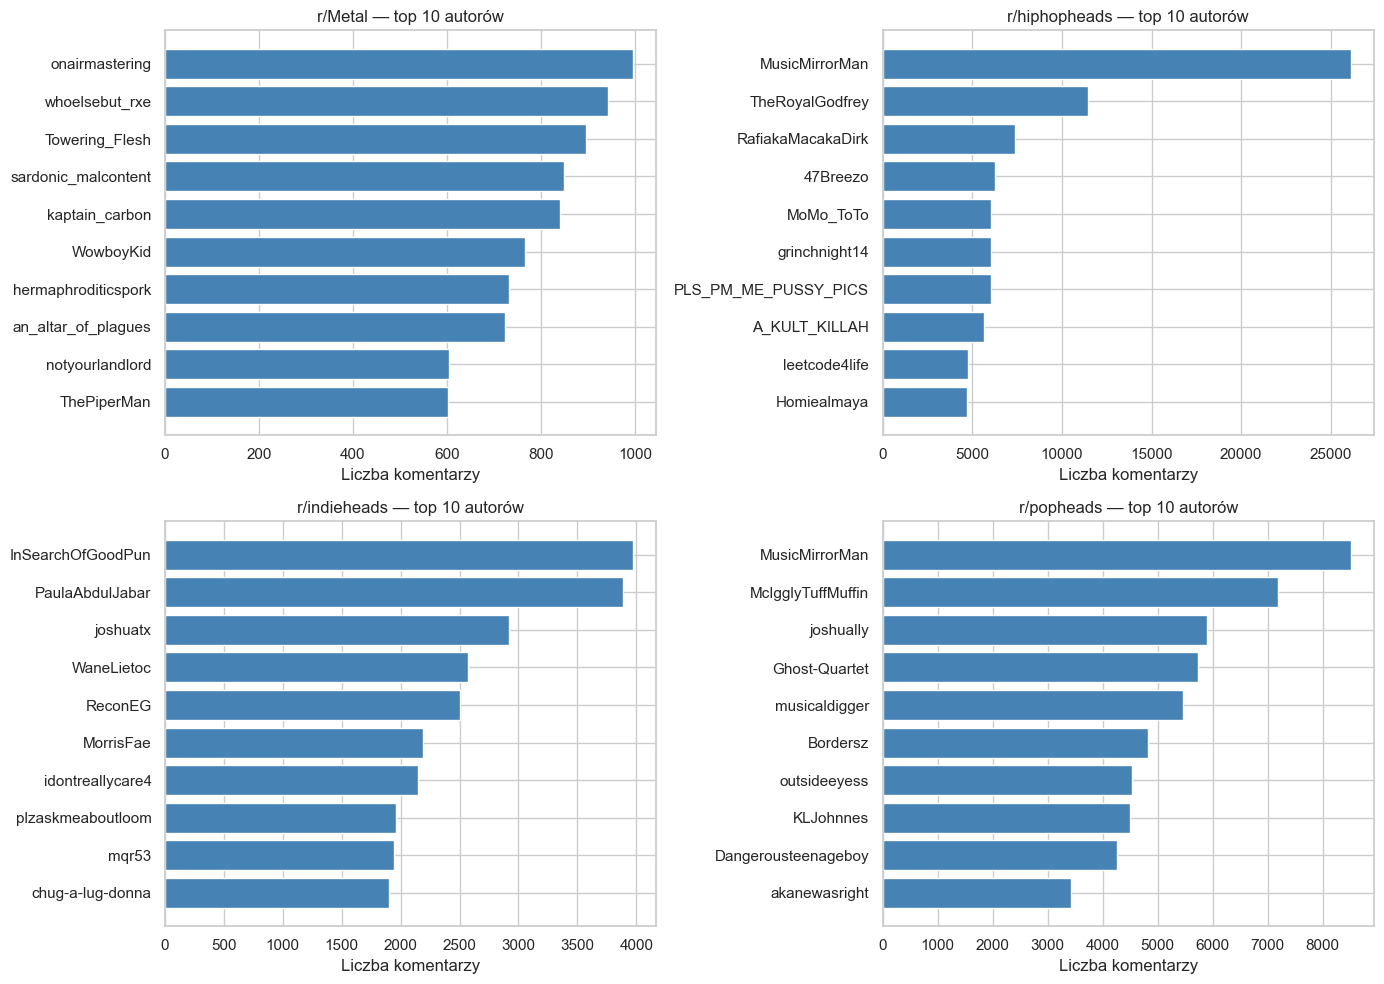

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (sub, group) in enumerate(df.groupby("subreddit")):
    top = group["author"].value_counts().head(10)
    axes[i].barh(top.index[::-1], top.values[::-1], color="steelblue")
    axes[i].set_title(f"r/{sub} — top 10 autorów")
    axes[i].set_xlabel("Liczba komentarzy")

plt.tight_layout()
plt.savefig("../outputs/figures/top_authors.png", dpi=150)
plt.show()

## 6. Kontrowersyjność i gilded

In [31]:
controversial = (
    df.groupby("subreddit")["controversiality"]
    .mean()
    .mul(100)
    .round(2)
    .rename("% kontrowersyjnych")
)

gilded = (
    df.groupby("subreddit")["gilded"]
    .sum()
    .rename("gilded łącznie")
)

pd.concat([controversial, gilded], axis=1)

,% kontrowersyjnych,gilded łącznie
subreddit,,
Metal,0.96,12
hiphopheads,3.65,708
indieheads,1.35,97
popheads,2.24,154


## Wnioski

- ...
- ...
- ...